In [442]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from sklearn.metrics import mean_absolute_error

A function for plotting the forecast VS real values

In [443]:
def plot_forecast(xaxis, yaxis_real, yaxis_forecast, mae, yhat_lower = None, yhat_upper = None, y_axis_forecast2 = None):
    fig = go.Figure()

    if yhat_lower is not None:
        fig.add_trace(go.Scatter(x = xaxis, y = yhat_upper, mode = 'lines', line=dict(width=0), showlegend = False))
        # fill = 'tonexty ==> Fill this area between the current trace and the previous trace
        fig.add_trace(go.Scatter(x = xaxis, y = yhat_lower, mode = 'lines', line=dict(width=0), 
                                 fillcolor='rgba(0, 114, 178, 0.2)', fill='tonexty', name = 'Uncertain Interval'))

    fig.add_trace(go.Scatter(x = xaxis, y = yaxis_real, mode = 'lines', name = 'Real'))

    if y_axis_forecast2 is not None:
        fig.add_trace(go.Scatter(x = xaxis, y = y_axis_forecast2, mode = 'lines',  name = 'Forecast Prophet'))
        fig.add_trace(go.Scatter(x = xaxis, y = yaxis_forecast, mode = 'lines',  name = 'Forecast SARIMA'))
        fig.update_layout(title = f'Real VS Forecasted electricity consumption Prophet & SARIMA',
                      xaxis_title = 'Dates', yaxis_title = 'Electricity consumption')
    else:
        fig.add_trace(go.Scatter(x = xaxis, y = yaxis_forecast, mode = 'lines',  name = 'Forecast'))
        fig.update_layout(title = f'Real VS Forecasted electricity consumption, MAE = {mae:0.2f}',
                      xaxis_title = 'Dates', yaxis_title = 'Electricity consumption')
    
    fig.show()

Reading the data of electricity consumption of France

In [444]:
original_data = pd.read_excel('consommation-quotidienne-brute.xlsx', parse_dates=True)

In [445]:
display(original_data)

,Date - Heure,Date,Heure,Consommation brute gaz (MW PCS 0°C) - GRTgaz,Statut - GRTgaz,Consommation brute gaz (MW PCS 0°C) - Teréga,Statut - Teréga,Consommation brute gaz totale (MW PCS 0°C),Consommation brute électricité (MW) - RTE,Statut - RTE,Consommation brute totale (MW)
0,2024-10-31T22:30:00+00:00,45596,23:30:00,NaN,NaN,NaN,NaN,NaN,47110,Consolidé,NaN
1,2024-10-31T22:00:00+00:00,45596,23:00:00,30998.0,Meilleur Statut,1734.0,Définitif,32732.0,47753,Consolidé,80485.0
2,2024-10-31T21:30:00+00:00,45596,22:30:00,NaN,NaN,NaN,NaN,NaN,48552,Consolidé,NaN
3,2024-10-31T21:00:00+00:00,45596,22:00:00,33674.0,Meilleur Statut,1867.0,Définitif,35541.0,47498,Consolidé,83039.0
4,2024-10-31T20:30:00+00:00,45596,21:30:00,NaN,NaN,NaN,NaN,NaN,46852,Consolidé,NaN
...,...,...,...,...,...,...,...,...,...,...,...
225019,2012-01-01T01:00:00+00:00,40909,02:00:00,52251.0,Définitif,3214.0,Définitif,55465.0,55531,Définitif,110996.0
225020,2012-01-01T00:30:00+00:00,40909,01:30:00,NaN,NaN,NaN,NaN,NaN,56075,Définitif,NaN
225021,2012-01-01T00:00:00+00:00,40909,01:00:00,52236.0,Définitif,3208.0,Définitif,55444.0,56230,Définitif,111674.0
225022,2011-12-31T23:30:00+00:00,40909,00:30:00,NaN,NaN,NaN,NaN,NaN,58314,Définitif,NaN


# Prepare Data and analysis

In [446]:
data = original_data[['Date - Heure', 'Consommation brute électricité (MW) - RTE']]

# The data is originally by 30 minutes, we will group it per day and average it.The data accepted by the Prophet model is YYYY-MM-DD per day data
data.loc[:,['Date - Heure']] = pd.to_datetime(data['Date - Heure']).dt.strftime('%Y-%m-%d')
data = data.groupby(['Date - Heure'], as_index = False).mean()
data = data.rename(columns = {'Consommation brute électricité (MW) - RTE':'y', 'Date - Heure': 'ds'})

In [448]:
display(data)

,ds,y
0,2011-12-31,58962.000000
1,2012-01-01,51328.041667
2,2012-01-02,61075.333333
3,2012-01-03,67773.520833
4,2012-01-04,68111.104167
...,...,...
4684,2024-10-27,41136.239130
4685,2024-10-28,46974.541667
4686,2024-10-29,48198.312500
4687,2024-10-30,48481.458333


In [449]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = data['ds'], y = data['y'], mode = 'lines', name = 'Real'))
fig.update_layout(xaxis_title = 'Time', yaxis_title = 'Electricity Consumption', title = 'Electricity consumption in France')
fig.show()

In [451]:
#train_data, test_data = train_test_split(prophet_data, test_size = 0.2, shuffle = False)
# To forecast 10 months ahead with 3 years of historical data
#train_data = data[((data['ds'] < '2024-01-01') & (data['ds'] >= '2021-01-01'))]
#test_data = data[data['ds'] >= '2024-01-01']

# To forecast 4 months ahead with 2 years of historical data
train_data = data[((data['ds'] < '2024-07-01') & (data['ds'] >= '2022-07-01'))]
test_data = data[data['ds'] >= '2024-07-01']

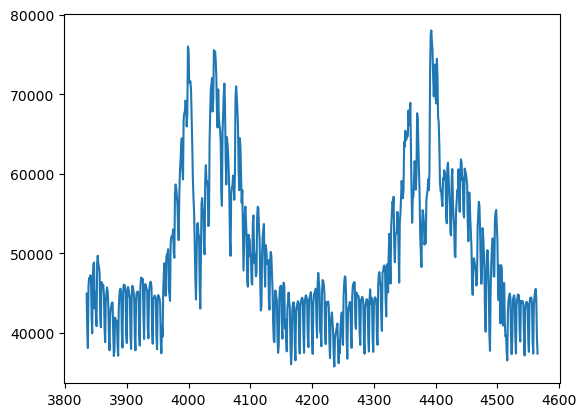

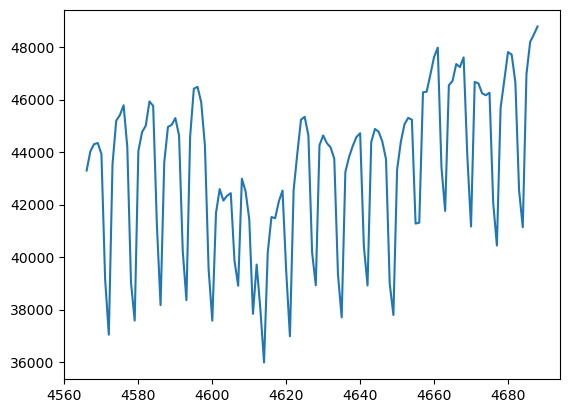

In [452]:
plt.plot(train_data['y'])
plt.show()
plt.plot(test_data['y'])
plt.show()

19:34:12 - cmdstanpy - INFO - Chain [1] start processing
19:34:12 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\anaconda3\envs\py311\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\USER\anaconda3\envs\py311\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\USER\anaconda3\envs\py311\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndar

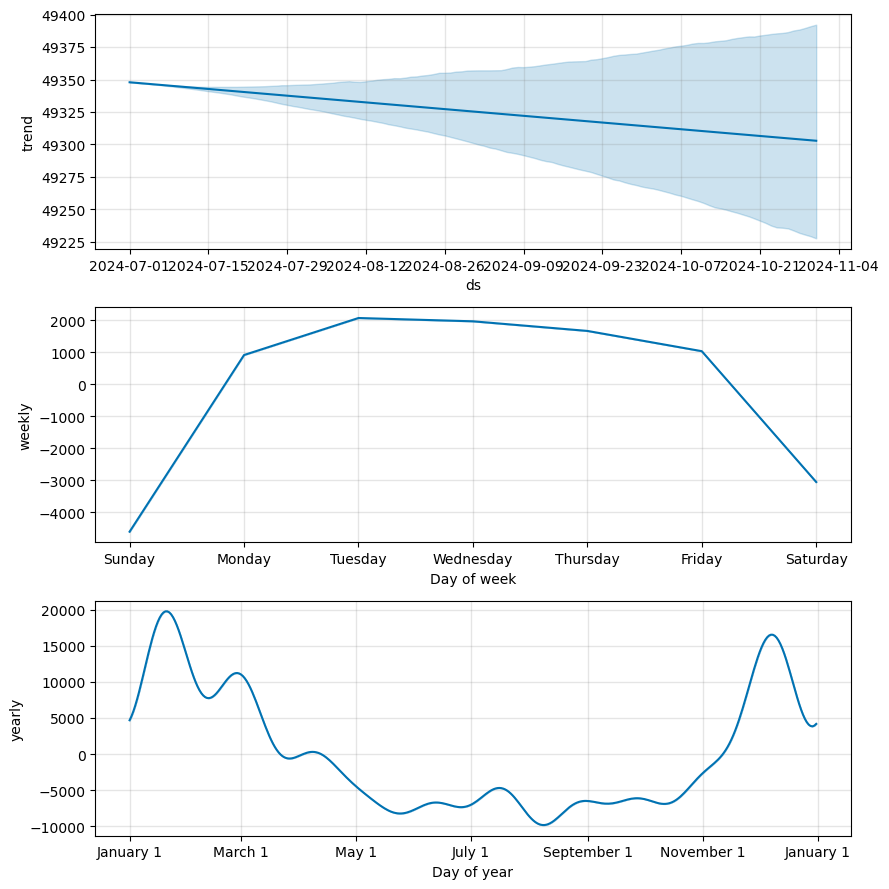

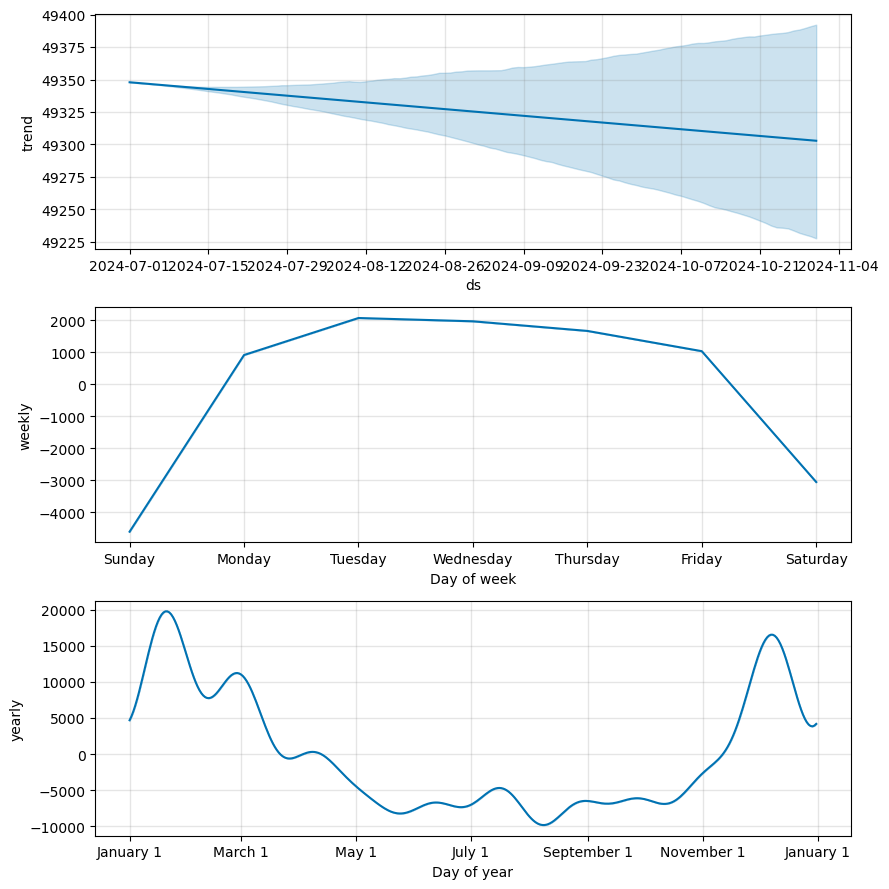

In [453]:
model_prophet = Prophet()
model_prophet.fit(train_data)
forecast_prophet = model_prophet.predict(test_data[['ds']])
mae_prophet = mean_absolute_error(test_data['y'], forecast_prophet['yhat'])

model_prophet.plot_components(forecast_prophet)

In [454]:
plot_forecast(test_data['ds'], test_data['y'], forecast_prophet['yhat'], mae_prophet,
              forecast_prophet['yhat_lower'], forecast_prophet['yhat_upper'])

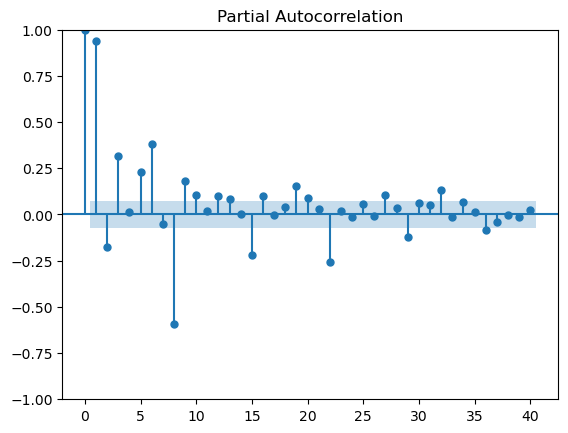

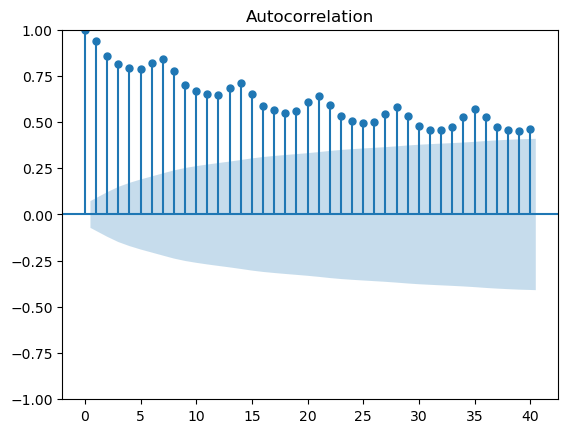

In [455]:
# Usefull for the SARIMA. 
# We extract the order of the AR from the PACF (the index of the significant lag represent the AR). AR = 1
plot_pacf(train_data['y'], lags = 40)
plt.show()

# We extract the order of MA from the ACF ()
plot_acf(train_data['y'], lags = 40)
plt.show()

#### Checking for stationarity. If the time series is non stationary we must identify the differencing that must be applied to make it stationary (how many differencing to make it stationary)

In [456]:
# quick test of stationary of the series
result = adfuller(data['y'])
print(result[1])

0.0001494406716956631


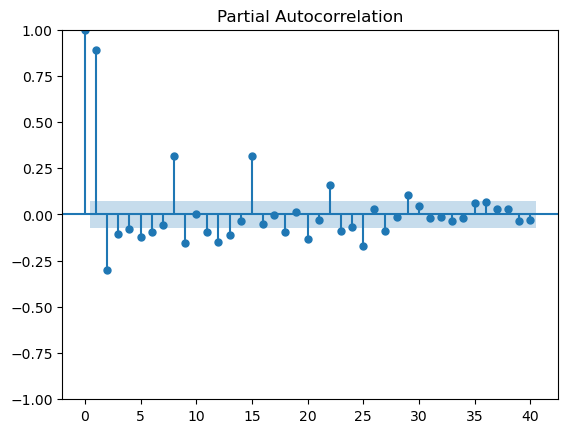

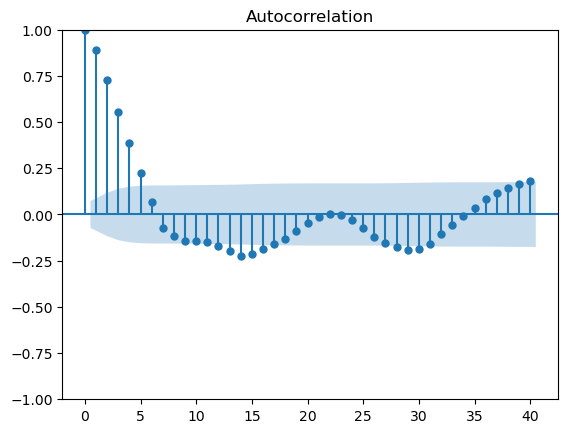

In [457]:
df_seasonal = train_data['y'].diff(7)

# Drop the first NaN value resulting from differencing
df_seasonal = df_seasonal.dropna()

# Usefull for the SARIMA. 
# We extract the order of the AR from the PACF (the index of the significant lag represent the AR). AR = 1
plot_pacf(df_seasonal, lags = 40)
plt.show()

# We extract the order of MA from the ACF ()
plot_acf(df_seasonal, lags = 40)
plt.show()

In [459]:
from statsmodels.tsa.seasonal import seasonal_decompose

#seasonal_decompose(train_data, model='additive', filt=None, period=None, two_sided=True, extrapolate_trend=0)

ts = train_data.copy()
ts.set_index('ds', inplace=True)

ts['y'] = ts['y'].fillna(0)
print(ts['y'].isna().sum())

0


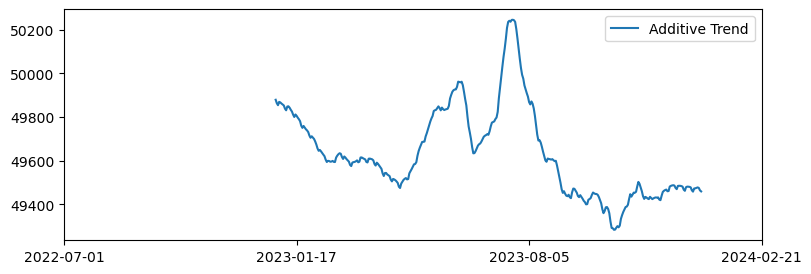

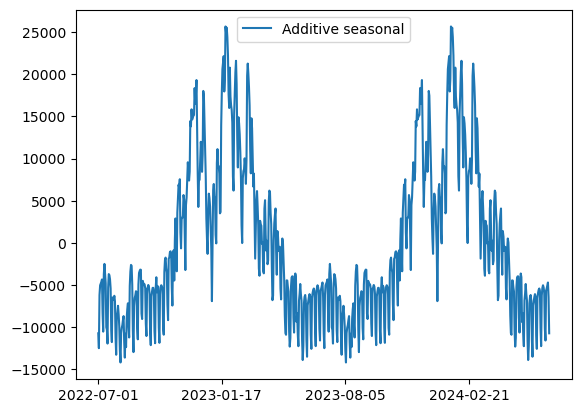

In [460]:
# must have 2 complete cycles requires 730 observations for daily data in our case.
if len(ts['y']) >= 730:
    result_add = seasonal_decompose(ts['y'], model='additive', period=365)

    plt.figure(figsize=(9, 3))

    plt.plot(result_add.trend, label='Additive Trend')
    plt.xticks(ts.index[0::200])
    plt.legend()
    plt.show()

    plt.plot(result_add.seasonal, label='Additive seasonal')
    plt.xticks(ts.index[0::200])
    plt.legend()
    plt.show()

In [461]:
# For the SARIMA model, the index must be the datetime of the series, and we better explicitly set the frequency of the data so we don't get warning during the fitting 
train_data_y = train_data['y'].copy()
train_data_y.index = pd.to_datetime(train_data['ds'])
train_data_y = train_data_y.asfreq('D')


In [ ]:
model_sarima = SARIMAX(train_data_y, order = (1, 0, 0), seasonal_order = (2, 1, 0, 7))#, enforce_stationarity=False, enforce_invertibility=False)

result = model_sarima.fit(disp=False)
forecast_sarima = result.get_forecast(steps = len(test_data))

forecast_y = forecast_sarima.predicted_mean

# The uncertain interval in the Prophet model is defaulted to 0.8, so I am picking the same width for the SARIMA interval
uncertain = forecast_sarima.conf_int(alpha = 0.80)

mae_sarima = mean_absolute_error(test_data['y'], forecast_y)


plot_forecast(test_data['ds'], test_data['y'], forecast_y, mae_sarima, uncertain['lower y'], uncertain['upper y'])

Hyperparameter tuning

In [ ]:
model_sarima2 = SARIMAX(train_data_y, order = (1, 0, 0), seasonal_order = (2, 1, 1, 7))#, enforce_stationarity=False, enforce_invertibility=False)

result2 = model_sarima2.fit(disp=False)

model_sarima3 = SARIMAX(train_data_y, order = (1, 0, 0), seasonal_order = (1, 1, 0, 7))#, enforce_stationarity=False, enforce_invertibility=False)

result3 = model_sarima3.fit(disp=False)

model_sarima4 = SARIMAX(train_data_y, order = (1, 0, 0), seasonal_order = (1, 1, 1, 7))#, enforce_stationarity=False, enforce_invertibility=False)

result4 = model_sarima4.fit(disp=False)

print(result.aic)
print(result2.aic)
print(result3.aic)
print(result4.aic)

13266.875785380907
13217.975726318953
13342.350309049525
13206.758551310657


The best SARIMA model

In [ ]:
forecast_sarima_best = result4.get_forecast(steps = len(test_data))

forecast_y_best = forecast_sarima_best.predicted_mean

# The uncertain interval in the Prophet model is defaulted to 0.8, so I am picking the same width for the SARIMA interval
uncertain_best = forecast_sarima_best.conf_int(alpha = 0.80)

mae_sarima_best = mean_absolute_error(test_data['y'], forecast_y_best)


plot_forecast(test_data['ds'], test_data['y'], forecast_y_best, mae_sarima_best, uncertain_best['lower y'], uncertain_best['upper y'])
# Best so far MAE = 1397


Best SARIMA model VS Prophet

In [465]:
plot_forecast(test_data['ds'], test_data['y'], forecast_y_best, mae_sarima_best, None, None, forecast_prophet['yhat'])

Long term forecast test with the same trained model of prophet and the Best SARIMA model (model 4, result4)

In [466]:
# The future dates
test_data.loc[:,['ds']] = pd.to_datetime(test_data['ds'])
future_dates = pd.date_range(start=test_data['ds'].iloc[0], end=test_data['ds'].iloc[0] + pd.Timedelta(days=500), freq="D")
future_dates = pd.to_datetime(future_dates).strftime('%Y-%m-%d')
print(future_dates)

Index(['2024-07-01', '2024-07-02', '2024-07-03', '2024-07-04', '2024-07-05',
       '2024-07-06', '2024-07-07', '2024-07-08', '2024-07-09', '2024-07-10',
       ...
       '2025-11-04', '2025-11-05', '2025-11-06', '2025-11-07', '2025-11-08',
       '2025-11-09', '2025-11-10', '2025-11-11', '2025-11-12', '2025-11-13'],
      dtype='object', length=501)


In [467]:
future_dates = pd.DataFrame({'ds': future_dates})
print(future_dates)

             ds
0    2024-07-01
1    2024-07-02
2    2024-07-03
3    2024-07-04
4    2024-07-05
..          ...
496  2025-11-09
497  2025-11-10
498  2025-11-11
499  2025-11-12
500  2025-11-13

[501 rows x 1 columns]


In [468]:
# prophet predict
forecast_prophet = model_prophet.predict(future_dates)

# SARIMA predict
forecast_sarima_best = result3.get_forecast(steps = len(future_dates))

forecast_y_best = forecast_sarima_best.predicted_mean

# The uncertain interval in the Prophet model is defaulted to 0.8, so I am picking the same width for the SARIMA interval
uncertain_best = forecast_sarima_best.conf_int(alpha = 0.80)

fig = go.Figure()


fig.add_trace(go.Scatter(x = future_dates['ds'], y = forecast_prophet['yhat'], mode = 'lines',  name = 'Forecast Prophet'))

fig.add_trace(go.Scatter(x = future_dates['ds'], y = forecast_y_best, mode = 'lines',  name = 'Forecast SARIMA'))

fig.update_layout(title = f'Real VS Forecasted electricity consumption Prophet & SARIMA',
              xaxis_title = 'Dates', yaxis_title = 'Electricity consumption')


fig.add_trace(go.Scatter(x = future_dates['ds'], y = uncertain_best['upper y'], mode = 'lines', line=dict(width=0), showlegend = False))
        # fill = 'tonexty ==> Fill this area between the current trace and the previous trace
fig.add_trace(go.Scatter(x = future_dates['ds'], y = uncertain_best['lower y'], mode = 'lines', line=dict(width=0), 
        fillcolor='rgba(0, 114, 178, 0.2)', fill='tonexty', name = 'Uncertain Interval'))

fig.show()